# 05 - True vs Pred

Builds per-dataset and grouped true-vs-pred scatter panels.

In [7]:
from pathlib import Path
import sys


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "mrmr").is_dir():
            return candidate
    raise FileNotFoundError("Could not locate project root containing mrmr/")


PROJECT_ROOT = find_project_root(Path.cwd())
NOTEBOOK_DIR = PROJECT_ROOT / "mrmr" / "viz" / "notebooks"
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

import importlib
import nb_utils as _nb_utils

_nb_utils = importlib.reload(_nb_utils)

build_mrmr_methods = _nb_utils.build_mrmr_methods
run_notebook_05 = _nb_utils.run_notebook_05

SETTING = ("binned_interpolation", "10%", "30")

SINGLE_DATASETS = [
    "bbh",
    "mmlu_pro",
    "arc_challenge",
]

GROUPED_SOURCES = {
    "openllm_filtered": [
        "ifeval",
        "mmlu_pro",
        "arc_challenge",
        "bbh",
        "musr",
    ],
    "openllm": [
        "ifeval",
        "openllm_math",
        "mmlu_pro",
        "arc_challenge",
        "bbh",
        "gpqa",
        "musr",
    ],
    "helm": [
        "commonsense",
        "gsm",
        "legalbench",
        "math",
        "med_qa",
        "mmlu",
    ],
}

METHODS_REQUESTED: list[str | tuple[str, ...]] = [
    "random_sampling",
    "anchor_points_weighted",
    "gpirt",
]
METHODS_REQUESTED += [
    (m, m.replace("5_", "_"))
    for m in build_mrmr_methods(degrees=[2], mi_ks=[5], objectives=["MIQ"], targets=["y"])
]

[PosixPath('/home/dg22309/Documents/mrmr_project/mrmr/viz/plots/05_true_vs_pred/true_vs_pred_bbh.pdf'), PosixPath('/home/dg22309/Documents/mrmr_project/mrmr/viz/plots/05_true_vs_pred/true_vs_pred_mmlu_pro.pdf'), PosixPath('/home/dg22309/Documents/mrmr_project/mrmr/viz/plots/05_true_vs_pred/true_vs_pred_arc_challenge.pdf'), PosixPath('/home/dg22309/Documents/mrmr_project/mrmr/viz/plots/05_true_vs_pred/true_vs_pred_grid_openllm_filtered.pdf'), PosixPath('/home/dg22309/Documents/mrmr_project/mrmr/viz/plots/05_true_vs_pred/true_vs_pred_grid_openllm.pdf'), PosixPath('/home/dg22309/Documents/mrmr_project/mrmr/viz/plots/05_true_vs_pred/true_vs_pred_grid_helm.pdf'), PosixPath('/home/dg22309/Documents/mrmr_project/mrmr/viz/plots/05_true_vs_pred/true_vs_pred_grid_continuous_big.pdf'), PosixPath('/home/dg22309/Documents/mrmr_project/mrmr/viz/plots/05_true_vs_pred/true_vs_pred_grid_passk_big.pdf')]
true_vs_pred_bbh.pdf


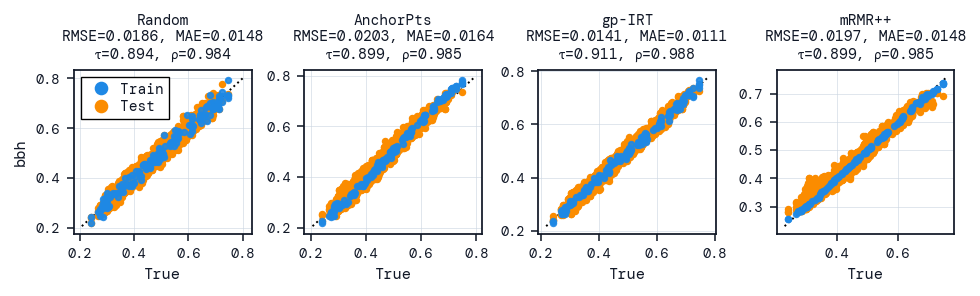

true_vs_pred_mmlu_pro.pdf


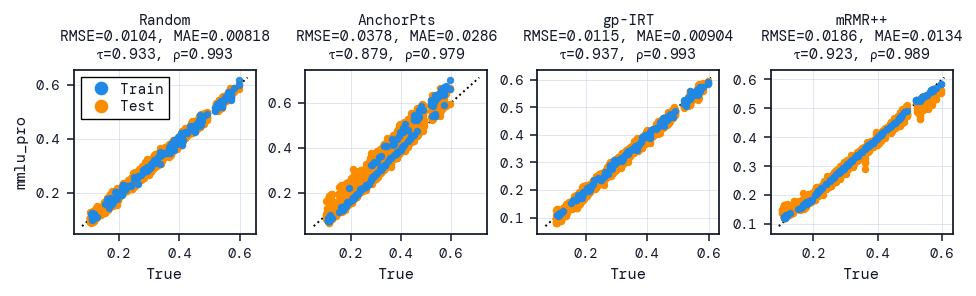

true_vs_pred_arc_challenge.pdf


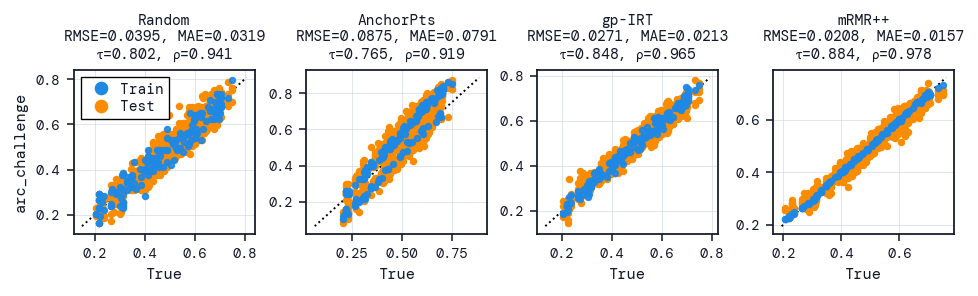

true_vs_pred_grid_openllm_filtered.pdf


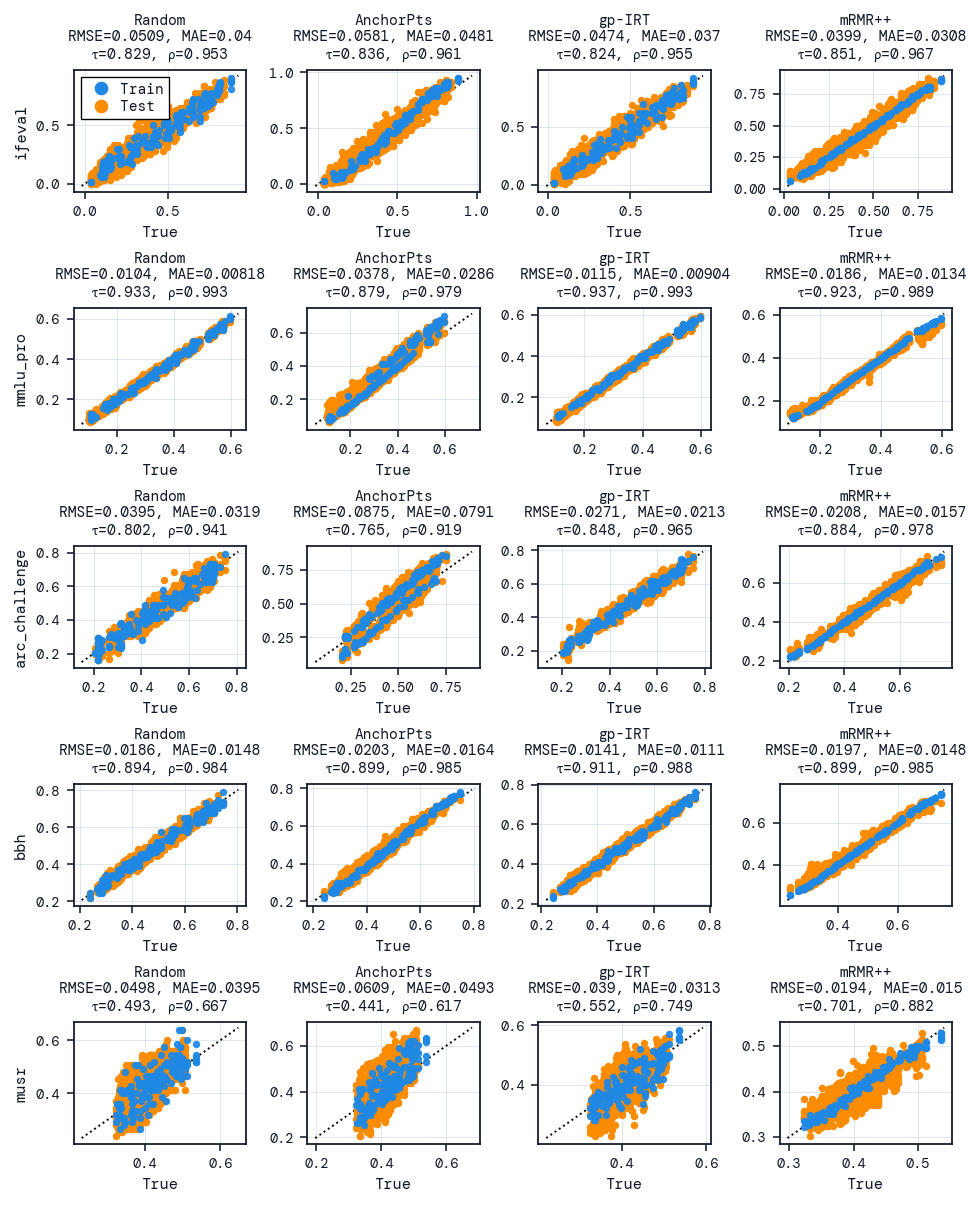

true_vs_pred_grid_openllm.pdf


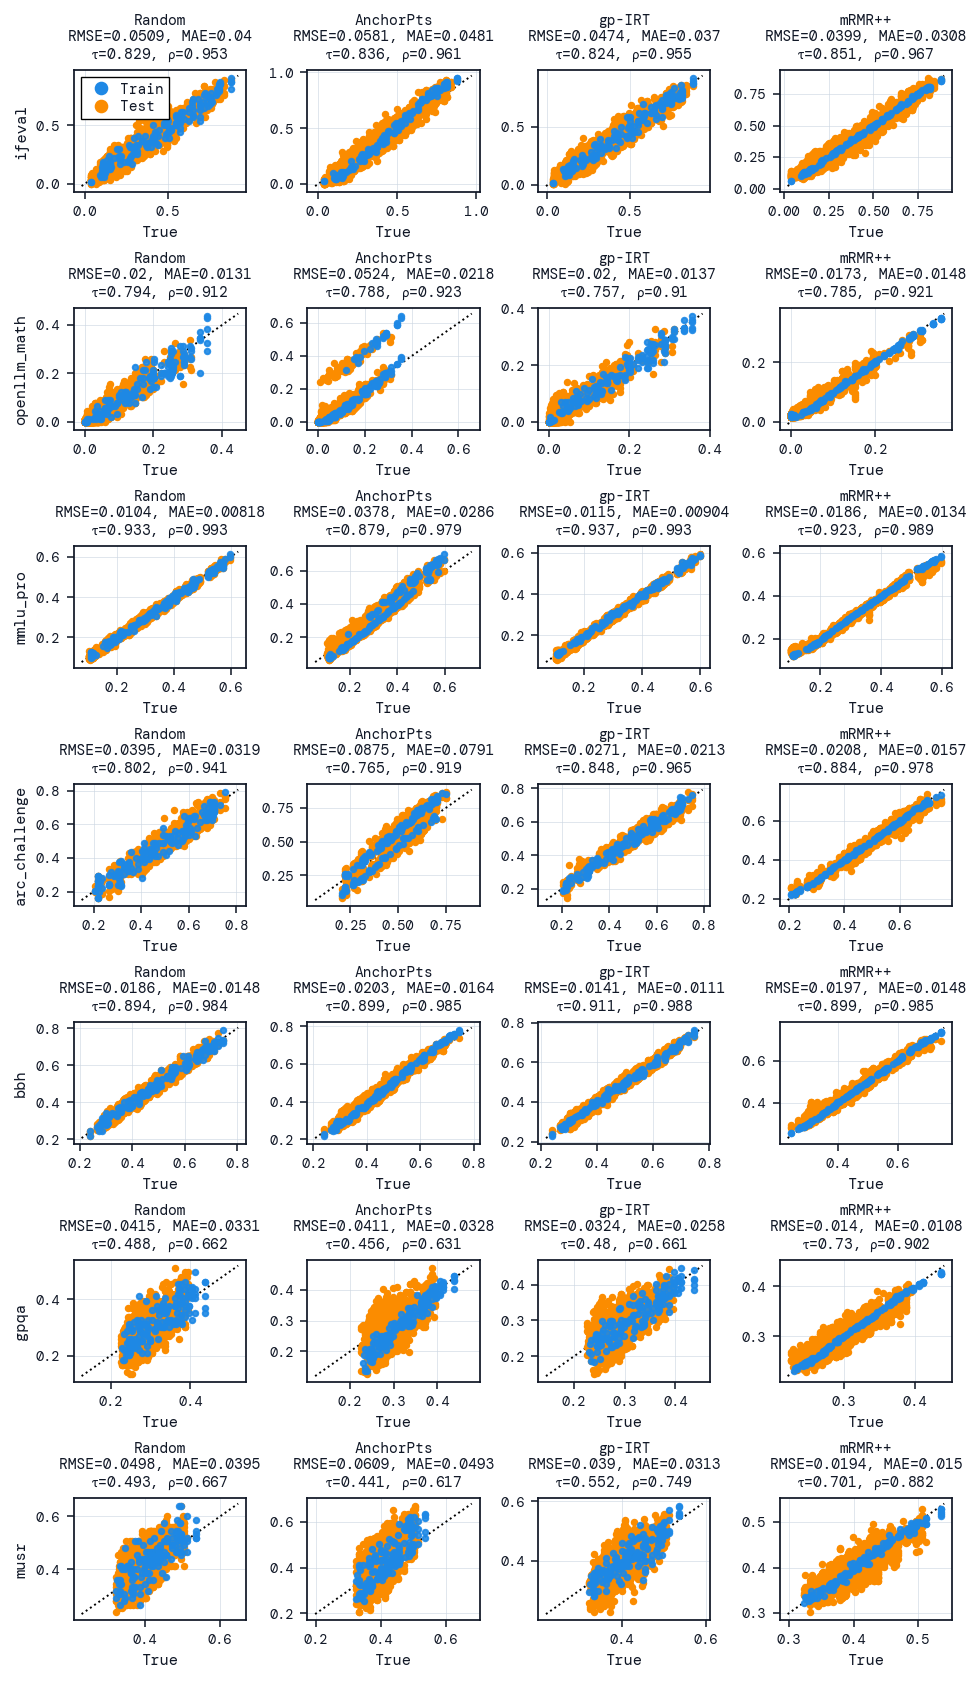

true_vs_pred_grid_helm.pdf


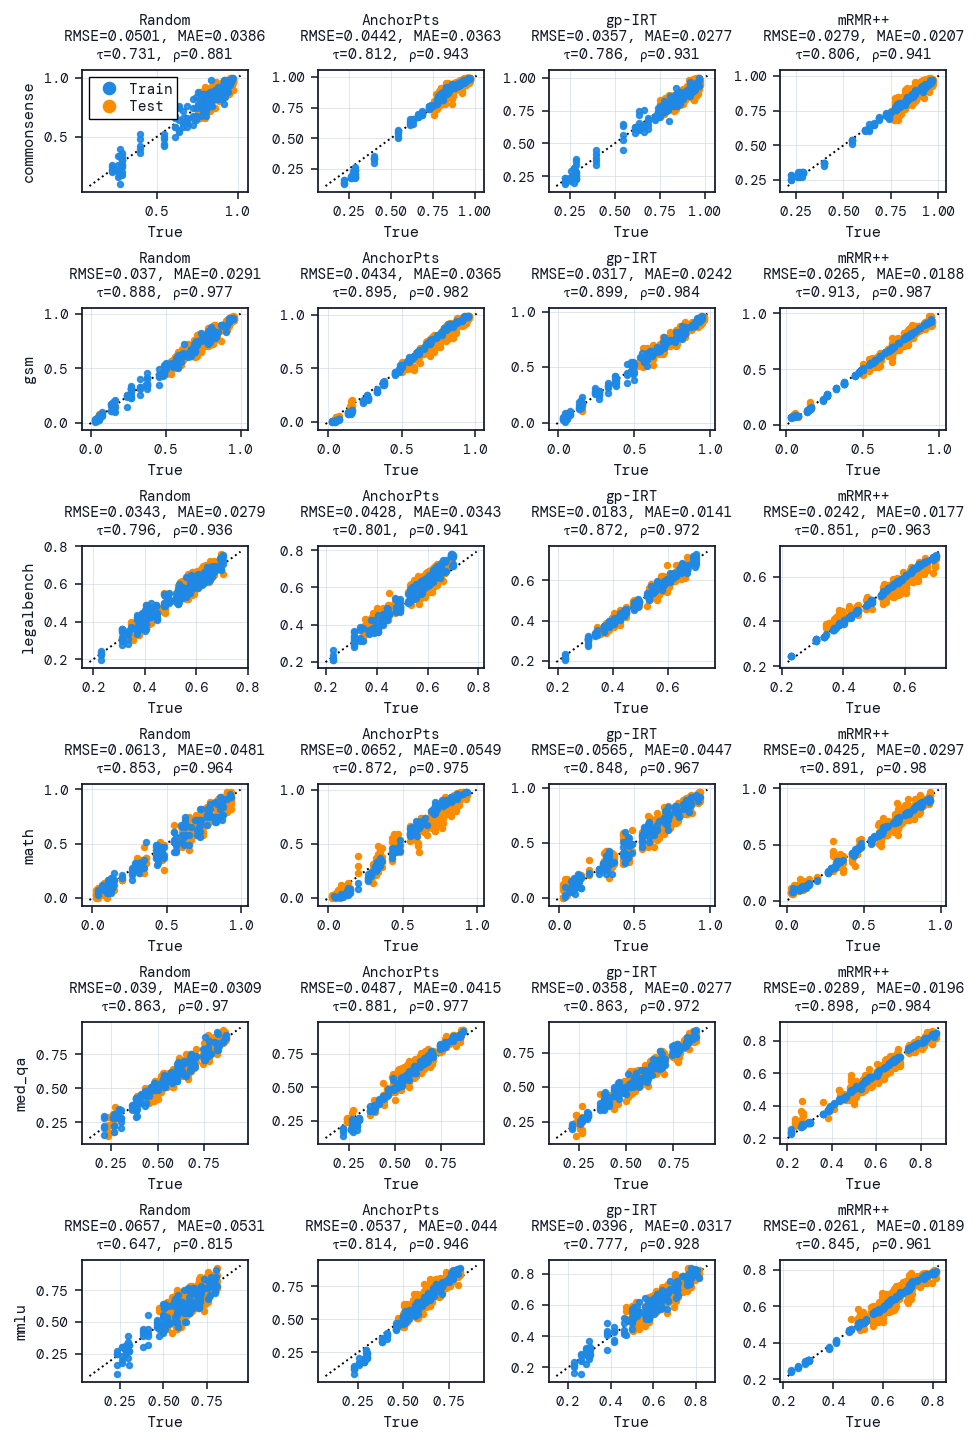

true_vs_pred_grid_continuous_big.pdf


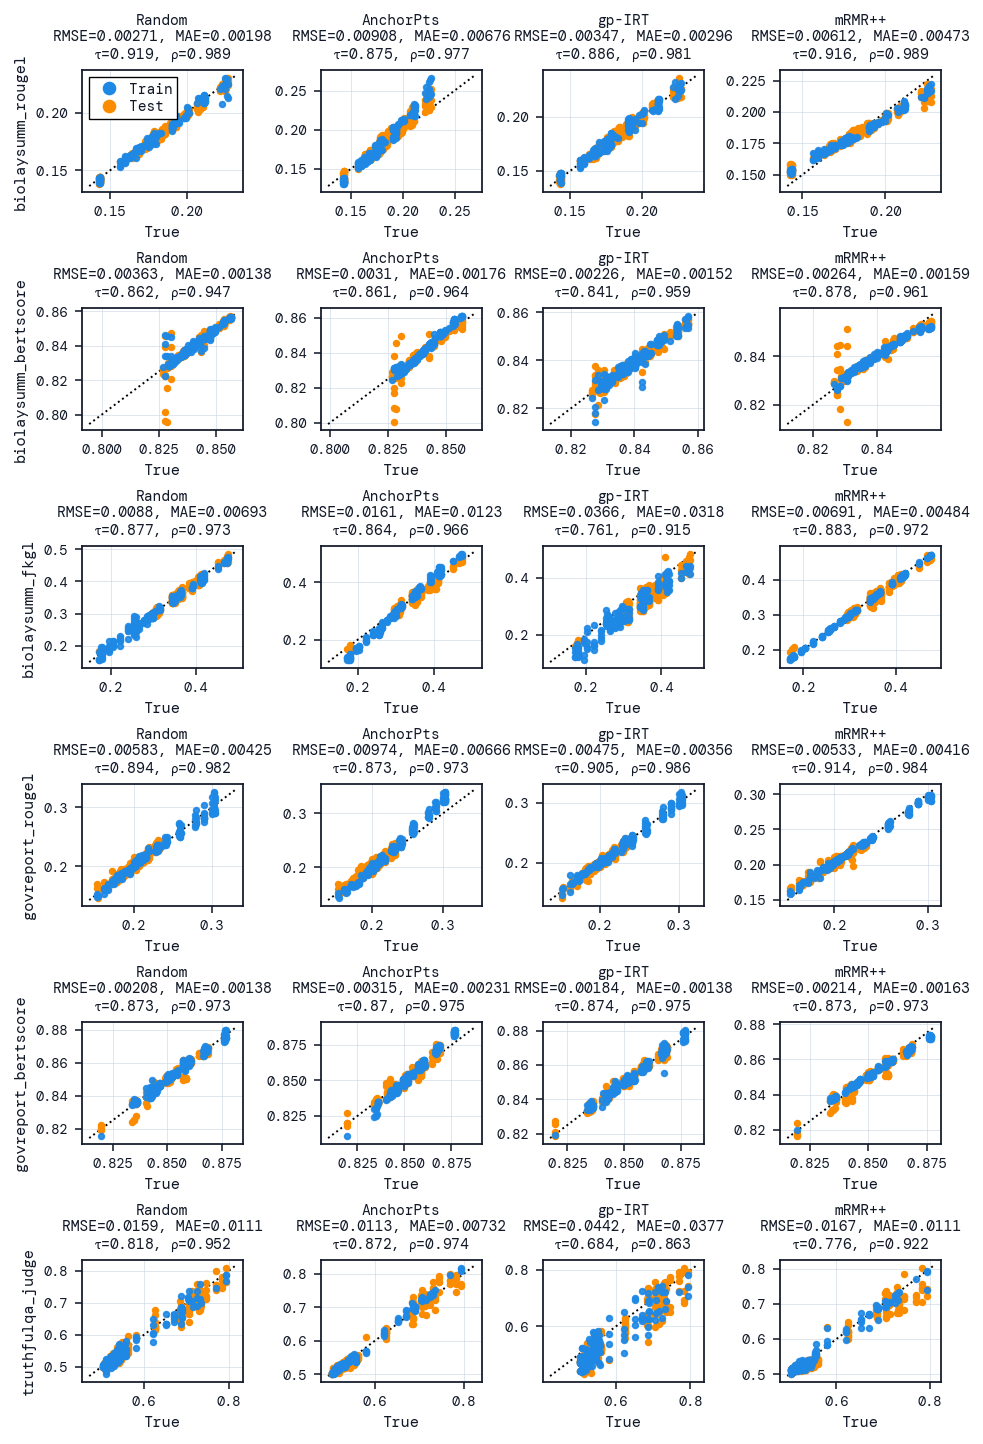

true_vs_pred_grid_passk_big.pdf


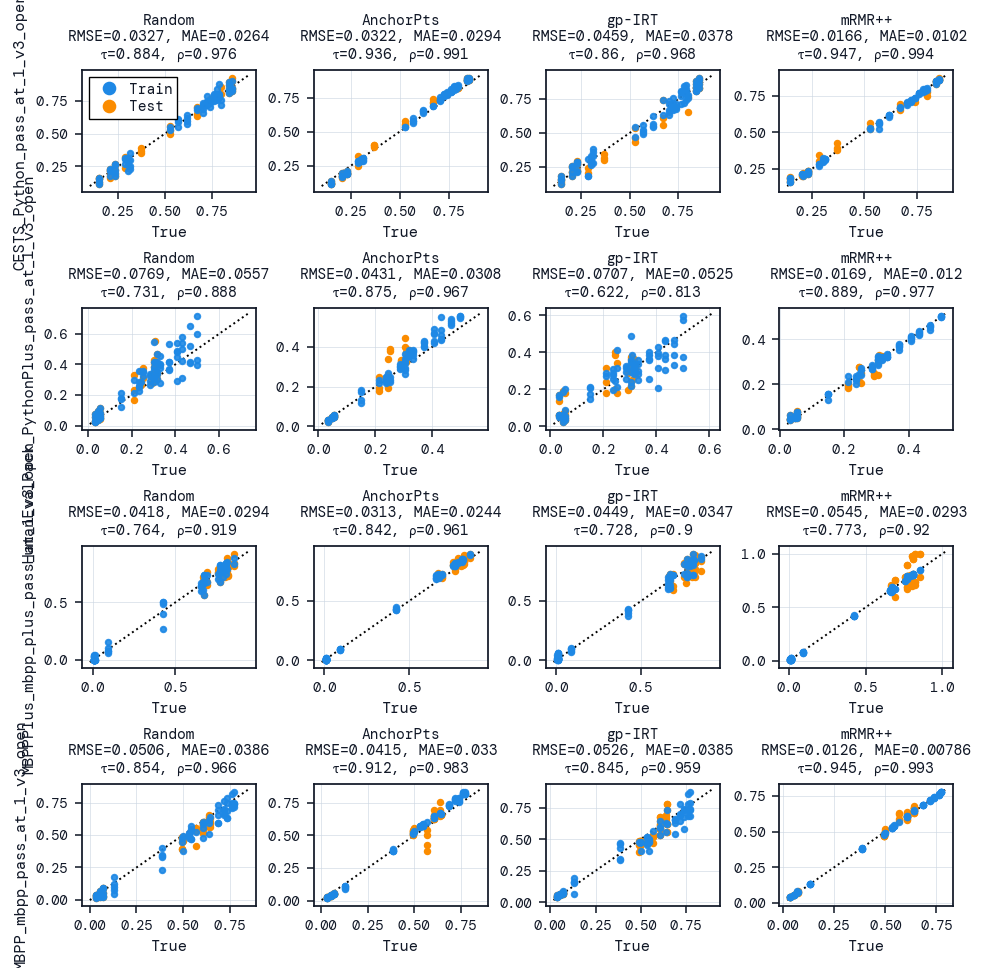


Training RMSE by benchmark and method:
               benchmark      method  train_rmse  n_train_points
0          arc_challenge   AnchorPts    0.081430             150
1          arc_challenge      Random    0.040107             150
2          arc_challenge      gp-IRT    0.019561             150
3          arc_challenge  mRMR (d=2)    0.005842             150
4                    bbh   AnchorPts    0.021420             150
..                   ...         ...         ...             ...
87  truthfulqa_bertscore  mRMR (d=2)    0.001407             150
88      truthfulqa_judge   AnchorPts    0.023341             150
89      truthfulqa_judge      Random    0.021987             150
90      truthfulqa_judge      gp-IRT    0.061822             150
91      truthfulqa_judge  mRMR (d=2)    0.015565             150

[92 rows x 4 columns]


,benchmark,method,train_rmse,n_train_points
0,arc_challenge,AnchorPts,0.081430,150
1,arc_challenge,Random,0.040107,150
2,arc_challenge,gp-IRT,0.019561,150
3,arc_challenge,mRMR (d=2),0.005842,150
4,bbh,AnchorPts,0.021420,150
...,...,...,...,...
87,truthfulqa_bertscore,mRMR (d=2),0.001407,150
88,truthfulqa_judge,AnchorPts,0.023341,150
89,truthfulqa_judge,Random,0.021987,150
90,truthfulqa_judge,gp-IRT,0.061822,150



Saved 5x4 arc_challenge seed grid plot to: /home/dg22309/Documents/mrmr_project/mrmr/viz/plots/05_true_vs_pred/true_vs_pred_arc_challenge_seeds_1_to_5_grid_5x4.pdf


In [8]:
outputs, figures = run_notebook_05(
    setting=SETTING,
    single_datasets=SINGLE_DATASETS,
    grouped_sources=GROUPED_SOURCES,
    methods_requested=METHODS_REQUESTED,
    save_outputs=True,
    show_saved_plots=False,
    return_figures=True,
    close_figures=False,
)

print(outputs)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

for key, fig in figures.items():
    print(key)
    display(fig)
    plt.close(fig)

setting_obj = _nb_utils.get_setting_flexible(*SETTING)
jbl_df = _nb_utils.load_setting_jbl(setting_obj)
methods = _nb_utils._select_existing_methods(list(METHODS_REQUESTED), set(jbl_df["method"]))

rmse_rows = []
for dataset in sorted(jbl_df["dataset"].dropna().astype(str).unique()):
    for method in methods:
        sub = jbl_df[(jbl_df["dataset"] == dataset) & (jbl_df["method"] == method)]
        train_true, train_pred = [], []
        for _, row in sub.iterrows():
            y_true = row.get("true_acc_train")
            y_pred = row.get("pred_acc_train")
            if y_true is not None and y_pred is not None:
                train_true.extend(y_true)
                train_pred.extend(y_pred)

        if len(train_true) == 0:
            rmse = np.nan
            n_train_points = 0
        else:
            true_arr = np.asarray(train_true, dtype=float)
            pred_arr = np.asarray(train_pred, dtype=float)
            valid = np.isfinite(true_arr) & np.isfinite(pred_arr)
            true_arr = true_arr[valid]
            pred_arr = pred_arr[valid]
            n_train_points = int(valid.sum())
            rmse = float(np.sqrt(np.mean((pred_arr - true_arr) ** 2))) if n_train_points else np.nan

        rmse_rows.append(
            {
                "benchmark": dataset,
                "method": _nb_utils.pretty_method_name(method, compact_anchor=True),
                "train_rmse": rmse,
                "n_train_points": n_train_points,
            }
        )

train_rmse_df = pd.DataFrame(rmse_rows).sort_values(["benchmark", "method"]).reset_index(drop=True)
print("\nTraining RMSE by benchmark and method:")
print(train_rmse_df)
display(train_rmse_df)

# Extra plot: arc_challenge as a 5x4 grid (seeds x methods),
# using the same sizing/styling as the full true-vs-pred plots.
arc_df = jbl_df[jbl_df["dataset"] == "arc_challenge"].copy()
seed_values = ["1", "2", "3", "4", "5"]
methods_arc = _nb_utils._select_existing_methods(list(METHODS_REQUESTED), set(arc_df["method"]))[:4]

if len(methods_arc) < 4:
    print(f"\nExpected 4 methods, found {len(methods_arc)} for arc_challenge; skipping 5x4 seed plot.")
else:
    arc_seed_blocks = []
    arc_seed_datasets = []
    for seed in seed_values:
        seed_label = f"arc_challenge (seed={seed})"
        block = arc_df[arc_df["seed"].astype(str) == seed].copy()
        block["dataset"] = seed_label
        arc_seed_blocks.append(block)
        arc_seed_datasets.append(seed_label)

    arc_seed_df = pd.concat(arc_seed_blocks, ignore_index=True) if arc_seed_blocks else pd.DataFrame()
    seed_grid_out = (
        PROJECT_ROOT
        / "mrmr"
        / "viz"
        / "plots"
        / "05_true_vs_pred"
        / "true_vs_pred_arc_challenge_seeds_1_to_5_grid_5x4.pdf"
    )

    if arc_seed_df.empty:
        print("\nCould not generate 5x4 arc_challenge seed grid plot (no seed data found).")
    else:
        seed_grid_path = _nb_utils._plot_true_vs_pred_grid(
            jbl_df=arc_seed_df,
            dataset_list=arc_seed_datasets,
            methods=methods_arc,
            output_path=seed_grid_out,
            row_height=1.7,
        )
        print(f"\nSaved 5x4 arc_challenge seed grid plot to: {seed_grid_path}")
